# GOAT algorithm for a closed system


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import gates, qeye, sigmax, sigmay, sigmaz, tensor
import qutip as qt
from qutip_qoc import Objective, optimize_pulses

def fidelity(gate, target_gate):
    """
    Fidelity used for unitary gates in qutip-qtrl and qutip-qoc
    """
    return np.abs(gate.overlap(target_gate) / target_gate.norm())


## Problem setup


In [2]:
omega = 0.1  # energy splitting
sx, sy, sz = sigmax(), sigmay(), sigmaz()

Hd = 1 / 2 * omega * sz
Hc = [sx, sy, sz]

# objective for optimization
initial_gate = qeye(2)
target_gate = gates.hadamard_transform()

times = np.linspace(0, np.pi / 2, 250)


In [18]:
# problem setup: slow effective model for controlled bring-up

import numpy as np
import qutip as qt
from qutip import tensor, qeye, sigmax, sigmay, sigmaz

MHz=2*np.pi*1e6

A1=95*MHz
A2=9*MHz

I=qeye(2)
sx=sigmax()
sy=sigmay()
sz=sigmaz()

def op3(a,b,c):
    return tensor(a,b,c)

# ordering: [electron,nucleus1,nucleus2]
Sx=op3(sx,I,I)
Sy=op3(sy,I,I)
Sz=op3(sz,I,I)

Ix1=op3(I,sx,I)
Iy1=op3(I,sy,I)
Iz1=op3(I,sz,I)

Ix2=op3(I,I,sx)
Iy2=op3(I,I,sy)
Iz2=op3(I,I,sz)

# slow effective drift
Hd=A1*Sz*Iz1+A2*Sz*Iz2

# simple effective controls
Hx=Sx
Hy=Sy
Hc=[Hx,Hy]

initial_gate=qt.qeye([2,2,2])

UXX=(1/2)*qt.Qobj(np.array([
    [1,0,0,1,1,0,0,-1],
    [0,1,1,0,0,1,-1,0],
    [0,1,1,0,0,-1,1,0],
    [1,0,0,1,-1,0,0,1],
    [1,0,0,-1,1,0,0,1],
    [0,1,-1,0,0,1,1,0],
    [0,-1,1,0,0,1,1,0],
    [-1,0,0,1,1,0,0,1],
],dtype=complex),dims=[[2,2,2],[2,2,2]])

target_gate=UXX

T=4e-6
times=np.linspace(0,T,1000)

## Guess


Fidelity: 0.499547379513109
max |Bx| [mT]: 0.49999938191429866
max |By| [mT]: 0.2999996291485792


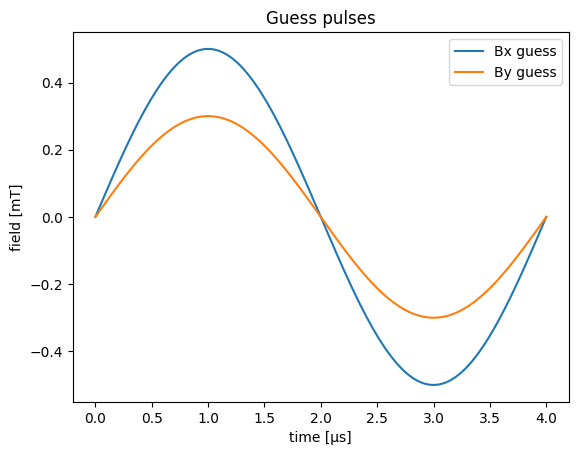

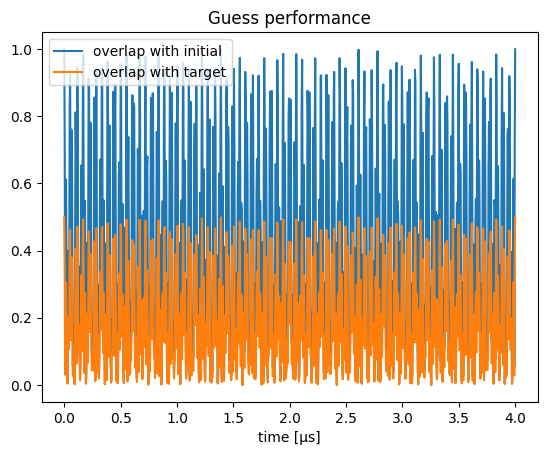

In [19]:
"""
goat_guess = [1, 1] # [A, w]
guess_pulse = goat_guess[0] * np.sin(goat_guess[1] * times) # A*sin(w*t)

H_guess = [Hd] + [[hc, guess_pulse] for hc in Hc] 
evolution_guess = qt.sesolve(H_guess, initial_gate, times)

print('Fidelity: ', fidelity(evolution_guess.states[-1], target_gate))

plt.plot(times, [fidelity(gate, initial_gate) for gate in evolution_guess.states], label="Overlap with initial gate")
plt.plot(times, [fidelity(gate, target_gate) for gate in evolution_guess.states], label="Overlap with target gate")
plt.title("Guess performance")
plt.xlabel('Time')
plt.legend()
plt.show()
"""

# guess

goat_guess_x=[5e-4,2*np.pi/T]
goat_guess_y=[3e-4,2*np.pi/T]

guess_pulse_x=goat_guess_x[0]*np.sin(goat_guess_x[1]*times)
guess_pulse_y=goat_guess_y[0]*np.sin(goat_guess_y[1]*times)

H_guess=[
    Hd,
    [Hc[0],guess_pulse_x],
    [Hc[1],guess_pulse_y],
]

evolution_guess=qt.sesolve(H_guess,initial_gate,times)

print("Fidelity:",fidelity(evolution_guess.states[-1],target_gate))
print("max |Bx| [mT]:",1e3*np.max(np.abs(guess_pulse_x)))
print("max |By| [mT]:",1e3*np.max(np.abs(guess_pulse_y)))

plt.plot(times*1e6,guess_pulse_x*1e3,label="Bx guess")
plt.plot(times*1e6,guess_pulse_y*1e3,label="By guess")
plt.xlabel("time [µs]")
plt.ylabel("field [mT]")
plt.title("Guess pulses")
plt.legend()
plt.show()

plt.plot(times*1e6,[fidelity(gate,initial_gate) for gate in evolution_guess.states],label="overlap with initial")
plt.plot(times*1e6,[fidelity(gate,target_gate) for gate in evolution_guess.states],label="overlap with target")
plt.xlabel("time [µs]")
plt.title("Guess performance")
plt.legend()
plt.show()


## GOAT algorithm


In [20]:
# control function
def sin(t, c):
    return c[0] * np.sin(c[1] * t) # A*sin(w*t), c=[A, w]

# derivatives
def grad_sin(t, c, idx):
    if idx == 0:  # w.r.t. c0
        return np.sin(c[1] * t)
    if idx == 1:  # w.r.t. c1
        return c[0] * np.cos(c[1] * t) * t
    if idx == 2:  # w.r.t. time
        return c[0] * np.cos(c[1] * t) * c[1]
    
H = [Hd] + [[hc, sin, {"grad": grad_sin}] for hc in Hc]


### a) not optimized over time


Infidelity: 0.5245741408326854


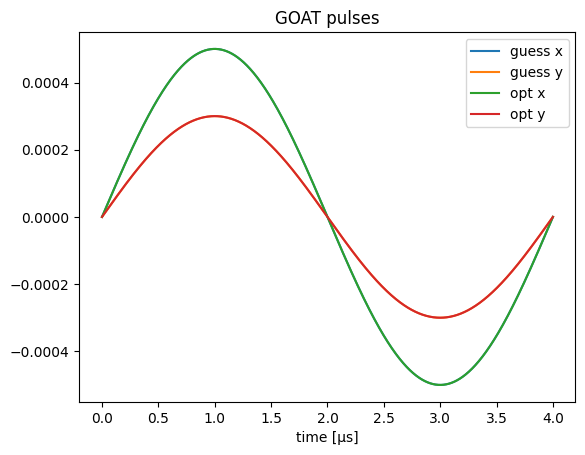

In [23]:
control_params={
    "x":{"guess":goat_guess_x,"bounds":[(-1,1),(0,2*np.pi/T)]},
    "y":{"guess":goat_guess_y,"bounds":[(-1,1),(0,2*np.pi/T)]},
}

res_goat=optimize_pulses(
    objectives=Objective(initial_gate,H,target_gate),
    control_parameters=control_params,
    tlist=times,
    algorithm_kwargs={
        "alg":"GOAT",
        "fid_err_targ":1e-3,
    },
    integrator_kwargs={
        "nsteps":200000
    }
)

print("Infidelity:",res_goat.infidelity)

plt.plot(times*1e6,guess_pulse_x,label="guess x")
plt.plot(times*1e6,guess_pulse_y,label="guess y")
plt.plot(times*1e6,res_goat.optimized_controls[0],label="opt x")
plt.plot(times*1e6,res_goat.optimized_controls[1],label="opt y")
plt.xlabel("time [µs]")
plt.title("GOAT pulses")
plt.legend()
plt.show()

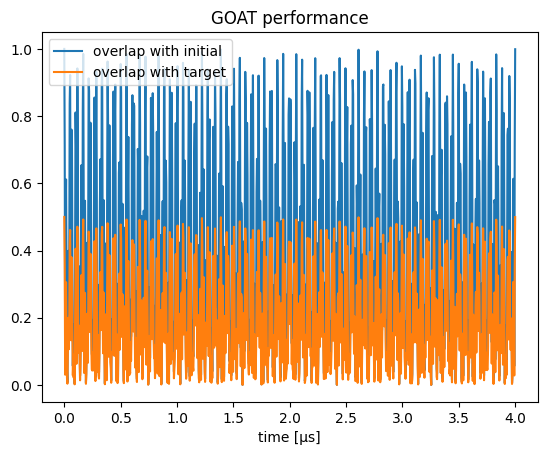

In [24]:
H_result=[
    Hd,
    [Hc[0],np.array(res_goat.optimized_controls[0])],
    [Hc[1],np.array(res_goat.optimized_controls[1])],
]

evolution=qt.sesolve(
    H_result,
    initial_gate,
    times,
    options={"nsteps":200000}
)

plt.plot(times*1e6,[fidelity(gate,initial_gate) for gate in evolution.states],label="overlap with initial")
plt.plot(times*1e6,[fidelity(gate,target_gate) for gate in evolution.states],label="overlap with target")
plt.xlabel("time [µs]")
plt.title("GOAT performance")
plt.legend()
plt.show()

### b) optimized over time


Infidelity: 0.5244368408231985
optimized_params: [[0.0005, 1570796.3267948967], [0.0003, 1570796.3267948967], [3.999959853468084e-06]]


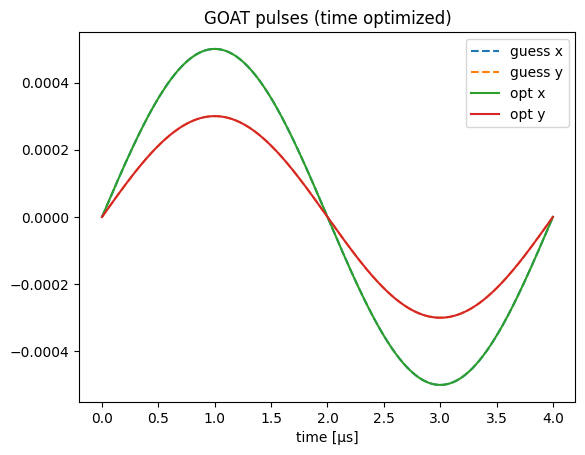

Optimized T [µs]: 3.999959853468084


In [29]:
control_params_time={
    "x":{"guess":goat_guess_x,"bounds":[(-1,1),(0,2*np.pi/T)]},
    "y":{"guess":goat_guess_y,"bounds":[(-1,1),(0,2*np.pi/T)]},
    "__time__":{"guess":T,"bounds":[(1e-6,8e-6)]},
}

res_goat_time=optimize_pulses(
    objectives=Objective(initial_gate,H,target_gate),
    control_parameters=control_params_time,
    tlist=times,
    algorithm_kwargs={
        "alg":"GOAT",
        "fid_err_targ":1e-3,
    },
    integrator_kwargs={
        "nsteps":200000
    }
)

print("Infidelity:",res_goat_time.infidelity)
print("optimized_params:",res_goat_time.optimized_params)

T_opt=res_goat_time.optimized_params[-1]
times_opt=np.linspace(0,T_opt,len(times))

plt.plot(times*1e6,guess_pulse_x,"--",label="guess x")
plt.plot(times*1e6,guess_pulse_y,"--",label="guess y")
plt.plot(times_opt*1e6,res_goat_time.optimized_controls[0],label="opt x")
plt.plot(times_opt*1e6,res_goat_time.optimized_controls[1],label="opt y")
plt.xlabel("time [µs]")
plt.title("GOAT pulses (time optimized)")
plt.legend()
plt.show()

print("Optimized T [µs]:",T_opt[0]*1e6)

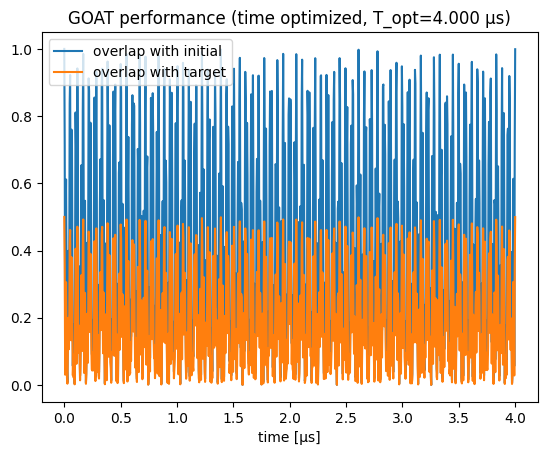

Optimized T [µs]: 3.999959853468084


In [30]:
T_opt=res_goat_time.optimized_params[-1][0]

H_result_time=[
    Hd,
    [Hc[0],np.array(res_goat_time.optimized_controls[0])],
    [Hc[1],np.array(res_goat_time.optimized_controls[1])],
]

evolution_time=qt.sesolve(
    H_result_time,
    initial_gate,
    times,
    options={"nsteps":200000}
)

plt.plot(times*1e6,[fidelity(gate,initial_gate) for gate in evolution_time.states],label="overlap with initial")
plt.plot(times*1e6,[fidelity(gate,target_gate) for gate in evolution_time.states],label="overlap with target")
plt.xlabel("time [µs]")
plt.title(f"GOAT performance (time optimized, T_opt={T_opt*1e6:.3f} µs)")
plt.legend()
plt.show()

print("Optimized T [µs]:",T_opt*1e6)

## Global optimization


Infidelity: 0.5062331587065592
optimized_params: [[-0.028332968039568696, 1570796.3267948967], [-0.1612441552987661, 1570796.052477108], [1e-06]]


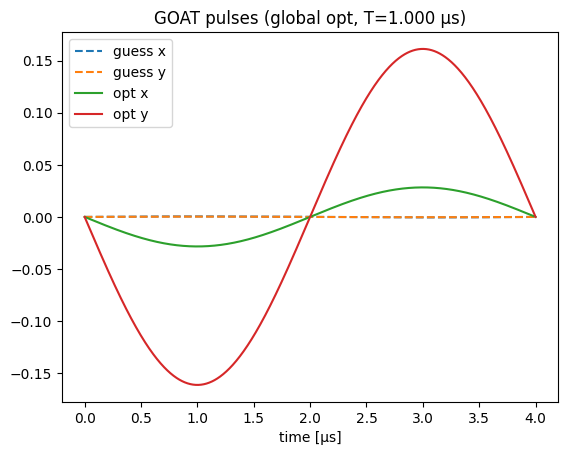

In [32]:
control_params_global={
    "x":{"guess":goat_guess_x,"bounds":[(-1,1),(0,2*np.pi/T)]},
    "y":{"guess":goat_guess_y,"bounds":[(-1,1),(0,2*np.pi/T)]},
    "__time__":{"guess":T,"bounds":[(1e-6,8e-6)]},
}

res_goat_global=optimize_pulses(
    objectives=Objective(initial_gate,H,target_gate),
    control_parameters=control_params_global,
    tlist=times,
    algorithm_kwargs={
        "alg":"GOAT",
        "fid_err_targ":1e-3,
    },
    optimizer_kwargs={
        "method":"basinhopping",
        "niter":10
    },
    integrator_kwargs={
        "nsteps":200000
    }
)

print("Infidelity:",res_goat_global.infidelity)
print("optimized_params:",res_goat_global.optimized_params)

T_global=res_goat_global.optimized_params[-1][0]

plt.plot(times*1e6,guess_pulse_x,"--",label="guess x")
plt.plot(times*1e6,guess_pulse_y,"--",label="guess y")
plt.plot(times*1e6,res_goat_global.optimized_controls[0],label="opt x")
plt.plot(times*1e6,res_goat_global.optimized_controls[1],label="opt y")
plt.xlabel("time [µs]")
plt.title(f"GOAT pulses (global opt, T={T_global*1e6:.3f} µs)")
plt.legend()
plt.show()

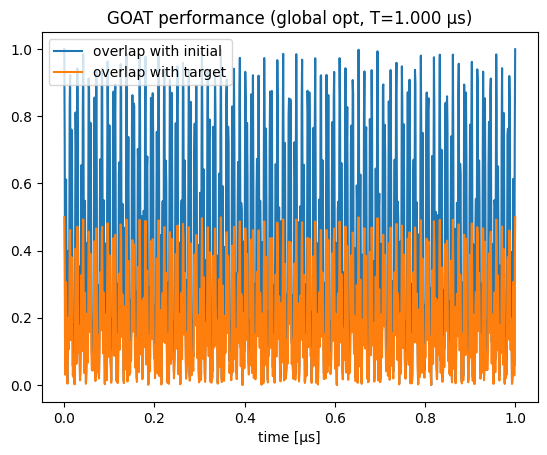

In [33]:
T_global=res_goat_global.optimized_params[-1][0]

H_result_global=[
    Hd,
    [Hc[0],np.array(res_goat_global.optimized_controls[0])],
    [Hc[1],np.array(res_goat_global.optimized_controls[1])],
]

evolution_global=qt.sesolve(
    H_result_global,
    initial_gate,
    times,
    options={"nsteps":200000}
)

times_rescaled=np.linspace(0,T_global,len(times))

plt.plot(times_rescaled*1e6,[fidelity(gate,initial_gate) for gate in evolution_global.states],label="overlap with initial")
plt.plot(times_rescaled*1e6,[fidelity(gate,target_gate) for gate in evolution_global.states],label="overlap with target")
plt.xlabel("time [µs]")
plt.title(f"GOAT performance (global opt, T={T_global*1e6:.3f} µs)")
plt.legend()
plt.show()

## Comparison


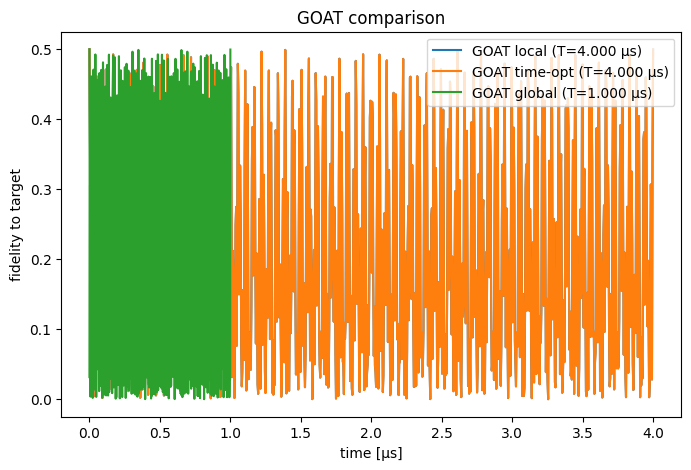

local infidelity:      0.5245741408326854
time-opt infidelity:   0.5244368408231985
global infidelity:     0.5062331587065592


In [35]:
plt.figure(figsize=(8,5))

plt.plot(times*1e6,[fidelity(gate,target_gate) for gate in evolution.states],
         label=f"GOAT local (T={T*1e6:.3f} µs)")

plt.plot(np.linspace(0,T_opt,len(times))*1e6,
         [fidelity(gate,target_gate) for gate in evolution_time.states],
         label=f"GOAT time-opt (T={T_opt*1e6:.3f} µs)")

plt.plot(np.linspace(0,T_global,len(times))*1e6,
         [fidelity(gate,target_gate) for gate in evolution_global.states],
         label=f"GOAT global (T={T_global*1e6:.3f} µs)")

plt.xlabel("time [µs]")
plt.ylabel("fidelity to target")
plt.title("GOAT comparison")
plt.legend()
plt.show()

print("local infidelity:     ",res_goat.infidelity)
print("time-opt infidelity:  ",res_goat_time.infidelity)
print("global infidelity:    ",res_goat_global.infidelity)

## Validation


In [36]:
assert res_goat.infidelity < 0.001
assert fidelity(evolution.states[-1], target_gate) > 1-0.001

assert res_goat_time.infidelity < 0.001
assert fidelity(evolution_time.states[-1], target_gate) > 1-0.001

assert res_goat_global.infidelity < 0.001
assert fidelity(evolution_global.states[-1], target_gate) > 1-0.001


AssertionError: 

In [13]:
qt.about()



QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.2.3
Numpy Version:      1.26.4
Scipy Version:      1.17.1
Cython Version:     None
Matplotlib Version: 3.10.8
Python Version:     3.11.15
Number of CPUs:     8
BLAS Info:          Accelerate
INTEL MKL Ext:      None
Platform Info:      Darwin (arm64)
Installation path:  /Users/johnkraus/anaconda3/envs/goat_env/lib/python3.11/site-packages/qutip

Installed QuTiP family packages
-------------------------------

qutip-qtrl: 0.1.5
qutip-ja